<font size="+3"><strong>Predicting housing prices in Bengaluru</strong></font>

**Importing Libraries**

In [1]:
!mamba install pandas
!mamba install seaborn
!mamba install scikit-learn
!mamba install -c conda-forge category_encoders
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #This library is needed to print heatmaps.
from sklearn.model_selection import train_test_split #train_test_split function is used to split data into train and test set randomly.
from category_encoders import OneHotEncoder #Used to encode non-numeric information in column location, for regression.
from sklearn.impute import SimpleImputer #Used for imputation, to fill missing values.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.6471000000238418 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environ

**Importing .csv file into a dataframe using Pandas**

In [3]:
df=pd.read_csv("BHP.csv")
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   balcony     12711 non-null  float64
 5   price       13320 non-null  float64
dtypes: float64(3), str(3)
memory usage: 468.4 KB


,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00
5,Whitefield,2 BHK,1170,2.0,1.0,38.00
6,Old Airport Road,4 BHK,2732,4.0,NaN,204.00
7,Rajaji Nagar,4 BHK,3300,4.0,NaN,600.00
8,Marathahalli,3 BHK,1310,3.0,1.0,63.25
9,Gandhi Bazar,6 Bedroom,1020,6.0,NaN,370.00


**Data Exploration & Cleaning**

In [4]:
#Dtype of column "total_sqft" is str, because it has values in a different format other than a normal floating point value.
df["is_float"] = pd.to_numeric(df['total_sqft'], errors='coerce').notna()
df["is_float"].value_counts()

is_float
True     13088
False      232
Name: count, dtype: int64

There happen to be some non-decimal entries, in column "total_sqft". The no. of such values are 232, which is less than 2%. So, the rows with such entries are dropped, by creating a mask.

In [5]:
df=df[df["is_float"]]
df.info()

<class 'pandas.DataFrame'>
Index: 13088 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13087 non-null  str    
 1   size        13079 non-null  str    
 2   total_sqft  13088 non-null  str    
 3   bath        13067 non-null  float64
 4   balcony     12534 non-null  float64
 5   price       13088 non-null  float64
 6   is_float    13088 non-null  bool   
dtypes: bool(1), float64(3), str(3)
memory usage: 575.2 KB


The entries in "Size" column, either end with BHK or Bedroom. Since, only the initial numeric values are needed for prediction, we split and make a separate column for it. 

In [6]:
df["bhk"]=df["size"].str.split(" ",expand=True)[0]
df.head()

,location,size,total_sqft,bath,balcony,price,is_float,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,True,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,True,4
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,True,3
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,True,3
4,Kothanur,2 BHK,1200,2.0,1.0,51.00,True,2


The "is_float" and "size" are dropped, since they are not useful for further analysis.

In [7]:
df.drop(columns=["size","is_float"], inplace=True)

In [8]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 13088 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13087 non-null  str    
 1   total_sqft  13088 non-null  str    
 2   bath        13067 non-null  float64
 3   balcony     12534 non-null  float64
 4   price       13088 non-null  float64
 5   bhk         13079 non-null  str    
dtypes: float64(3), str(3)
memory usage: 562.4 KB


,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2


In [9]:
df["total_sqft"]=df["total_sqft"].astype(float)
df["bhk"]=df["bhk"].astype(float)
df.info()

<class 'pandas.DataFrame'>
Index: 13088 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13087 non-null  str    
 1   total_sqft  13088 non-null  float64
 2   bath        13067 non-null  float64
 3   balcony     12534 non-null  float64
 4   price       13088 non-null  float64
 5   bhk         13079 non-null  float64
dtypes: float64(5), str(1)
memory usage: 664.6 KB


**Removing Outliers**

In [10]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,13088.000000,13067.000000,12534.000000,13088.000000,13079.000000
mean,1553.756048,2.692355,1.602760,112.594935,2.805796
std,1204.980729,1.336911,0.804278,149.694328,1.294781
min,1.000000,1.000000,0.000000,8.000000,1.000000
25%,1100.000000,2.000000,1.000000,50.000000,2.000000
50%,1275.000000,2.000000,2.000000,72.000000,3.000000
75%,1673.250000,3.000000,2.000000,120.000000,3.000000
max,52272.000000,40.000000,3.000000,3600.000000,43.000000


In [11]:
df = df[df["price"] <160]
df= df[df["price"] >40]
df = df[df["total_sqft"] < 2000]
df=df[df["total_sqft"] > 800]
df = df[df["bath"] < 5]
df.describe()

,total_sqft,bath,balcony,price,bhk
count,8109.000000,8109.000000,7961.000000,8109.000000,8109.000000
mean,1331.239706,2.335430,1.634845,74.224271,2.509064
std,254.786262,0.557015,0.759487,26.886551,0.610364
min,804.100000,1.000000,0.000000,40.050000,1.000000
25%,1150.000000,2.000000,1.000000,53.400000,2.000000
50%,1270.000000,2.000000,2.000000,67.000000,2.000000
75%,1500.000000,3.000000,2.000000,90.000000,3.000000
max,1999.000000,4.000000,3.000000,158.000000,8.000000


**Checking for Multi-Collinearity**

Our Target is "Price". We will be using the other columns as features. We are going to check for Multi Collinearity within the features.

<Axes: >

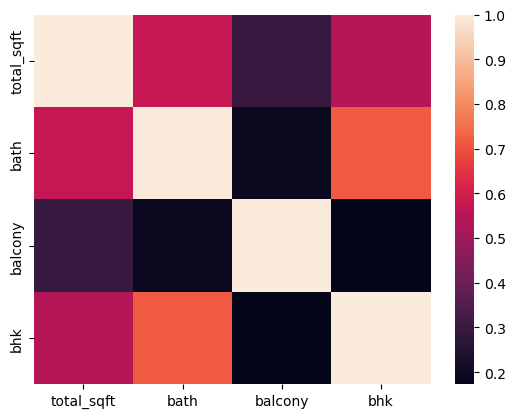

In [12]:
corr1 = df.select_dtypes("number").drop(columns="price").corr()
sns.heatmap(corr1)

The heat map shows strong correlation between bhk and bath. We need to drop either bhk and bath.

In [13]:
print(df["price"].corr(df["bath"]),df["price"].corr(df["bhk"]))

0.5060481381096391 0.4341332662146486


The above results imply that "bath" is more strongly correlated to "price", than bhk. So, we drop "bhk".

In [14]:
df.drop(columns="bhk",inplace=True)

In [15]:
df["price"].describe()
#df.head()
df.describe()

,total_sqft,bath,balcony,price
count,8109.000000,8109.000000,7961.000000,8109.000000
mean,1331.239706,2.335430,1.634845,74.224271
std,254.786262,0.557015,0.759487,26.886551
min,804.100000,1.000000,0.000000,40.050000
25%,1150.000000,2.000000,1.000000,53.400000
50%,1270.000000,2.000000,2.000000,67.000000
75%,1500.000000,3.000000,2.000000,90.000000
max,1999.000000,4.000000,3.000000,158.000000


**Choosing Features and Target for Linear Regression**

In [16]:
features=["total_sqft","bath","balcony","location"]
target=["price"]
X=df[features]
y=df[target]

**Splitting data randomly**

In [17]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

**Modelling using a Pipeline**

In [18]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    LinearRegression()
)
model.fit(X_train,y_train)

/lib/python3.13/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,['location']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


**Model Evaluation**

In [19]:
print("Training MAE:", mean_absolute_error(model.predict(X_train),y_train))

Training MAE: 11.283301299370004


In [20]:
print("Test MAE:", mean_absolute_error(model.predict(X_test),y_test))

Test MAE: 13.345132899505254


In [21]:
print(df["price"].mean())

74.22427118017018
